# Understanding the Weibull Plot

A **Weibull plot** is a probability plot specifically designed to test whether data follows a **Weibull distribution** — the standard model for **lifetime / reliability / time-to-failure** data. The key idea is to transform the axes so that Weibull-distributed data falls on a straight line, allowing visual assessment of fit and parameter estimation from the line's slope and intercept.

**Why Weibull?** The Weibull distribution is extremely flexible — by changing its shape parameter β it models:
- β < 1: decreasing failure rate (early failures / infant mortality)
- β = 1: constant failure rate (exponential, random failures)
- β > 1: increasing failure rate (wear-out failures)

**How the plot works:**

For Weibull CDF: F(t) = 1 − exp(−(t/η)^β)

Taking double log:  ln(ln(1/(1−F))) = β·ln(t) − β·ln(η)

Plotting ln(ln(1/(1−F))) on y vs ln(t) on x → **straight line** if Weibull holds.
- **Slope** = β (shape parameter)
- **x-intercept** = ln(η) (scale parameter)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

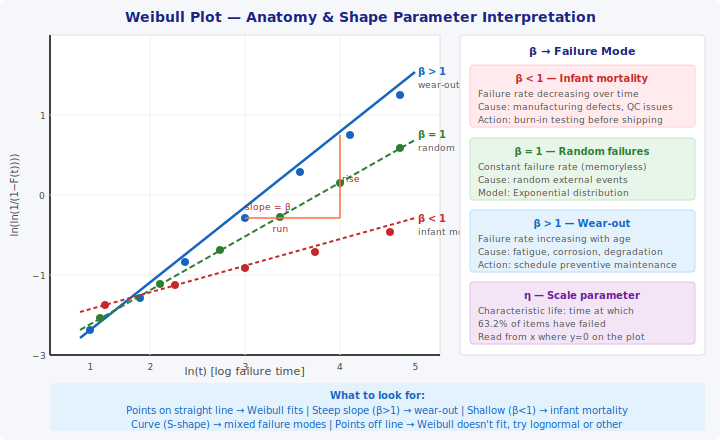

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Weibull Plot — Anatomy &amp; Shape Parameter Interpretation</text>

  <!-- ── MAIN WEIBULL PLOT ── -->
  <rect x="50" y="35" width="390" height="320" fill="white" stroke="#E0E0E0"/>

  <!-- Axes -->
  <line x1="50" y1="355" x2="440" y2="355" stroke="#424242" stroke-width="2"/>
  <line x1="50" y1="355" x2="50"  y2="35"  stroke="#424242" stroke-width="2"/>

  <!-- Grid -->
  <line x1="50" y1="275" x2="440" y2="275" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="50" y1="195" x2="440" y2="195" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="50" y1="115" x2="440" y2="115" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="150" y1="35" x2="150" y2="355" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="245" y1="35" x2="245" y2="355" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="340" y1="35" x2="340" y2="355" stroke="#F0F0F0" stroke-width="1"/>

  <!-- Axis labels -->
  <text x="245" y="375" text-anchor="middle" font-size="11" fill="#424242">ln(t)  [log failure time]</text>
  <text x="18" y="195" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 18 195)">ln(ln(1/(1−F(t))))</text>

  <!-- Tick labels -->
  <text x="45" y="359" text-anchor="end" font-size="9" fill="#424242">−3</text>
  <text x="45" y="279" text-anchor="end" font-size="9" fill="#424242">−1</text>
  <text x="45" y="199" text-anchor="end" font-size="9" fill="#424242">0</text>
  <text x="45" y="119" text-anchor="end" font-size="9" fill="#424242">1</text>
  <text x="90"  y="370" text-anchor="middle" font-size="9" fill="#424242">1</text>
  <text x="150" y="370" text-anchor="middle" font-size="9" fill="#424242">2</text>
  <text x="245" y="370" text-anchor="middle" font-size="9" fill="#424242">3</text>
  <text x="340" y="370" text-anchor="middle" font-size="9" fill="#424242">4</text>
  <text x="415" y="370" text-anchor="middle" font-size="9" fill="#424242">5</text>

  <!-- Case 1: β > 1 (steep slope, wear-out) — blue line -->
  <line x1="80" y1="338" x2="415" y2="72" stroke="#1565C0" stroke-width="2.5"/>
  <circle cx="90"  cy="330" r="4" fill="#1565C0"/>
  <circle cx="140" cy="298" r="4" fill="#1565C0"/>
  <circle cx="185" cy="262" r="4" fill="#1565C0"/>
  <circle cx="245" cy="218" r="4" fill="#1565C0"/>
  <circle cx="300" cy="172" r="4" fill="#1565C0"/>
  <circle cx="350" cy="135" r="4" fill="#1565C0"/>
  <circle cx="400" cy="95"  r="4" fill="#1565C0"/>
  <text x="418" y="75" font-size="10" font-weight="bold" fill="#1565C0">β &gt; 1</text>
  <text x="418" y="88" font-size="9" fill="#555">wear-out</text>

  <!-- Case 2: β = 1 (slope=1, exponential) — green line -->
  <line x1="80" y1="330" x2="415" y2="140" stroke="#2E7D32" stroke-width="2" stroke-dasharray="6,3"/>
  <circle cx="100" cy="318" r="4" fill="#2E7D32"/>
  <circle cx="160" cy="284" r="4" fill="#2E7D32"/>
  <circle cx="220" cy="250" r="4" fill="#2E7D32"/>
  <circle cx="280" cy="217" r="4" fill="#2E7D32"/>
  <circle cx="340" cy="183" r="4" fill="#2E7D32"/>
  <circle cx="400" cy="148" r="4" fill="#2E7D32"/>
  <text x="418" y="138" font-size="10" font-weight="bold" fill="#2E7D32">β = 1</text>
  <text x="418" y="151" font-size="9" fill="#555">random</text>

  <!-- Case 3: β < 1 (shallow slope, infant mortality) — red line -->
  <line x1="80" y1="312" x2="415" y2="218" stroke="#C62828" stroke-width="2" stroke-dasharray="4,3"/>
  <circle cx="105" cy="305" r="4" fill="#C62828"/>
  <circle cx="175" cy="285" r="4" fill="#C62828"/>
  <circle cx="245" cy="268" r="4" fill="#C62828"/>
  <circle cx="315" cy="252" r="4" fill="#C62828"/>
  <circle cx="390" cy="232" r="4" fill="#C62828"/>
  <text x="418" y="222" font-size="10" font-weight="bold" fill="#C62828">β &lt; 1</text>
  <text x="418" y="235" font-size="9" fill="#555">infant mort.</text>

  <!-- Slope annotation -->
  <line x1="245" y1="218" x2="340" y2="218" stroke="#FF7043" stroke-width="1.5"/>
  <line x1="340" y1="218" x2="340" y2="135" stroke="#FF7043" stroke-width="1.5"/>
  <text x="342" y="182" font-size="9" fill="#B71C1C">rise</text>
  <text x="280" y="232" text-anchor="middle" font-size="9" fill="#B71C1C">run</text>
  <text x="245" y="210" font-size="9" fill="#B71C1C">slope = β</text>

  <!-- ── RIGHT PANEL: β interpretation ── -->
  <rect x="460" y="35" width="245" height="320" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="582" y="55" text-anchor="middle" font-size="11" font-weight="bold" fill="#1A237E">β → Failure Mode</text>

  <rect x="470" y="65" width="225" height="62" fill="#FFEBEE" stroke="#FFCDD2" rx="3"/>
  <text x="582" y="82" text-anchor="middle" font-size="10" font-weight="bold" fill="#C62828">β &lt; 1 — Infant mortality</text>
  <text x="478" y="97"  font-size="9" fill="#555">Failure rate decreasing over time</text>
  <text x="478" y="110" font-size="9" fill="#555">Cause: manufacturing defects, QC issues</text>
  <text x="478" y="123" font-size="9" fill="#555">Action: burn-in testing before shipping</text>

  <rect x="470" y="138" width="225" height="62" fill="#E8F5E9" stroke="#C8E6C9" rx="3"/>
  <text x="582" y="155" text-anchor="middle" font-size="10" font-weight="bold" fill="#2E7D32">β = 1 — Random failures</text>
  <text x="478" y="170" font-size="9" fill="#555">Constant failure rate (memoryless)</text>
  <text x="478" y="183" font-size="9" fill="#555">Cause: random external events</text>
  <text x="478" y="196" font-size="9" fill="#555">Model: Exponential distribution</text>

  <rect x="470" y="210" width="225" height="62" fill="#E3F2FD" stroke="#BBDEFB" rx="3"/>
  <text x="582" y="227" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">β &gt; 1 — Wear-out</text>
  <text x="478" y="242" font-size="9" fill="#555">Failure rate increasing with age</text>
  <text x="478" y="255" font-size="9" fill="#555">Cause: fatigue, corrosion, degradation</text>
  <text x="478" y="268" font-size="9" fill="#555">Action: schedule preventive maintenance</text>

  <rect x="470" y="282" width="225" height="62" fill="#F3E5F5" stroke="#E1BEE7" rx="3"/>
  <text x="582" y="299" text-anchor="middle" font-size="10" font-weight="bold" fill="#6A1B9A">η — Scale parameter</text>
  <text x="478" y="314" font-size="9" fill="#555">Characteristic life: time at which</text>
  <text x="478" y="327" font-size="9" fill="#555">63.2% of items have failed</text>
  <text x="478" y="340" font-size="9" fill="#555">Read from x where y=0 on the plot</text>

  <!-- Takeaway -->
  <rect x="50" y="383" width="655" height="48" fill="#E3F2FD" rx="4"/>
  <text x="377" y="399" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="377" y="414" text-anchor="middle" font-size="10" fill="#1565C0">Points on straight line → Weibull fits   |   Steep slope (β&gt;1) → wear-out   |   Shallow (β&lt;1) → infant mortality</text>
  <text x="377" y="428" text-anchor="middle" font-size="10" fill="#1565C0">Curve (S-shape) → mixed failure modes   |   Points off line → Weibull doesn't fit, try lognormal or other</text>
</svg>
"""
display(SVG(_svg))

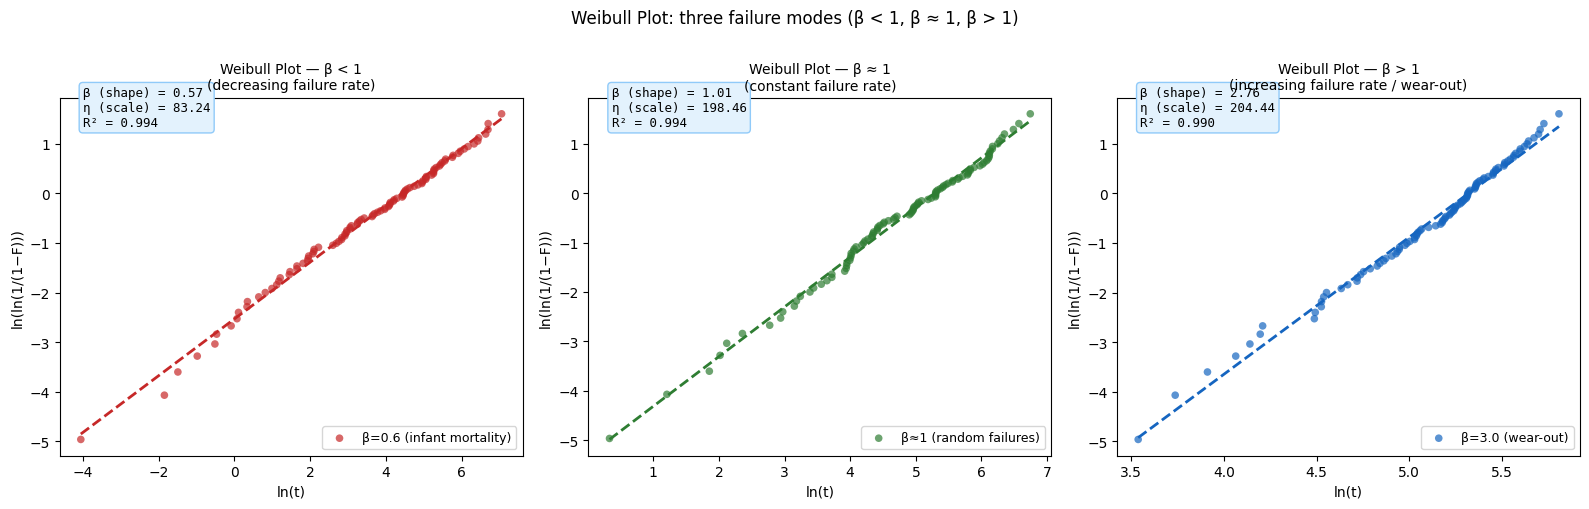

In [3]:
def weibull_plot(t, label="Data", ax=None, color='#1565C0'):
    """Weibull probability plot: ln(ln(1/(1-F))) vs ln(t)."""
    n = len(t)
    t_sorted = np.sort(t)
    # Median rank approximation (Benard's formula)
    i = np.arange(1, n+1)
    F = (i - 0.3) / (n + 0.4)
    y = np.log(np.log(1 / (1 - F)))
    x = np.log(t_sorted)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, color=color, alpha=0.7, s=30, edgecolors='none', label=label)

    # Fit line
    slope, intercept, r, *_ = stats.linregress(x, y)
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, slope*x_line + intercept, '--', color=color, linewidth=2)

    # β = slope; η = exp(-intercept/slope)
    beta = slope
    eta  = np.exp(-intercept / slope)
    ax.text(0.05, 0.92, f'β (shape) = {beta:.2f}\nη (scale) = {eta:.2f}\nR² = {r**2:.3f}',
            transform=ax.transAxes, fontsize=9, family='monospace',
            bbox=dict(facecolor='#E3F2FD', edgecolor='#90CAF9', boxstyle='round'))
    return ax

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# β < 1: infant mortality (shape < 1)
t_infant = np.random.weibull(0.6, 100) * 100
weibull_plot(t_infant, label='β=0.6 (infant mortality)', ax=axes[0], color='#C62828')
axes[0].set_title('Weibull Plot — β < 1\n(decreasing failure rate)', fontsize=10)
axes[0].set_xlabel('ln(t)')
axes[0].set_ylabel('ln(ln(1/(1−F)))')
axes[0].legend(fontsize=9)

# β = 1: exponential (random failures)
t_random = np.random.exponential(scale=200, size=100)
weibull_plot(t_random, label='β≈1 (random failures)', ax=axes[1], color='#2E7D32')
axes[1].set_title('Weibull Plot — β ≈ 1\n(constant failure rate)', fontsize=10)
axes[1].set_xlabel('ln(t)')
axes[1].set_ylabel('ln(ln(1/(1−F)))')
axes[1].legend(fontsize=9)

# β > 1: wear-out
t_wearout = np.random.weibull(3.0, 100) * 200
weibull_plot(t_wearout, label='β=3.0 (wear-out)', ax=axes[2], color='#1565C0')
axes[2].set_title('Weibull Plot — β > 1\n(increasing failure rate / wear-out)', fontsize=10)
axes[2].set_xlabel('ln(t)')
axes[2].set_ylabel('ln(ln(1/(1−F)))')
axes[2].legend(fontsize=9)

plt.suptitle('Weibull Plot: three failure modes (β < 1, β ≈ 1, β > 1)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Domain** | Reliability / survival analysis — time-to-failure data |
| **Straight line** | Weibull distribution fits the data |
| **β (slope)** | Shape parameter — determines failure mode |
| **β < 1** | Infant mortality — decreasing hazard; screen with burn-in |
| **β = 1** | Random failures — exponential distribution; constant hazard |
| **β > 1** | Wear-out — increasing hazard; plan preventive maintenance |
| **η (scale)** | Characteristic life — 63.2% of items fail by this time |
| **Curved line** | Mixed failure modes — consider mixture models |
| **vs Normal Q-Q** | Normal Q-Q tests normality; Weibull plot tests Weibull fit |
| **vs exponential** | Weibull generalises exponential; always try Weibull first for lifetimes |